**Análise e Pré Processamento de dados**

 - "Arrumar" / "Preencher" o dataset
 - Retirar dados não utilizáveis
 - Tirar primeiras impressões
 - Tratar dados "errados"

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
dataset = sns.load_dataset('titanic')
df = pd.DataFrame(data=dataset)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Tratando dados nulos**

*O que podemos fazer com dados nulos?* 

1 - Substituir os valores por médias ou medianas

2 - Excluir os dados (Colunas ou linhas)

3 - Imputação extradificada

4 - Imputação por regra

In [79]:
#Tratando Dados Nulos de idade

df['age'].isnull().value_counts()

age
False    714
True     177
Name: count, dtype: int64

<Axes: xlabel='pclass', ylabel='age'>

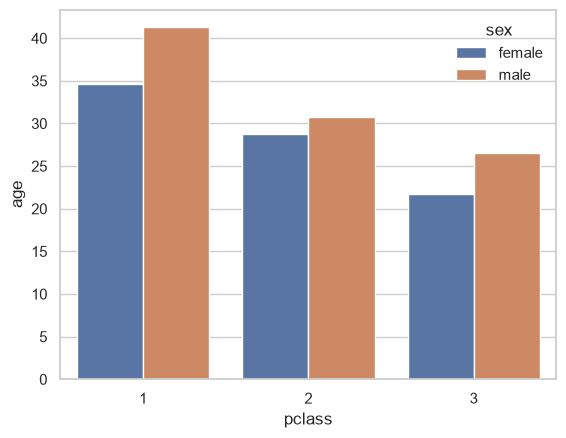

In [80]:

sns.barplot(data=df, x='pclass', y='age', hue='sex', errorbar=None)


In [81]:
#Subtituindo missing values com a mediana de subgrupos, 'class' e 'sex'

df['age'] = df.groupby(['pclass', 'sex'], group_keys=False)['age'].apply(lambda x: x.fillna(x.median()))

In [82]:
df['age'].isnull().value_counts()

age
False    891
Name: count, dtype: int64

In [83]:
#Colunas desnecessárias com dados repetidos

df = df.drop('embark_town', axis=1);
df = df.drop('class', axis=1)
df = df.drop('adult_male', axis=1)
df = df.drop('deck', axis=1)
df = df.drop('alive', axis=1)
df = df.drop('who', axis=1)

In [84]:
df['embarked'].isnull().sum()

np.int64(2)

In [85]:
df = df.dropna(subset=['embarked'])

**Análises**

*Heatmap de correlação*

 - Olhar a correlação entre variáveis

In [86]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


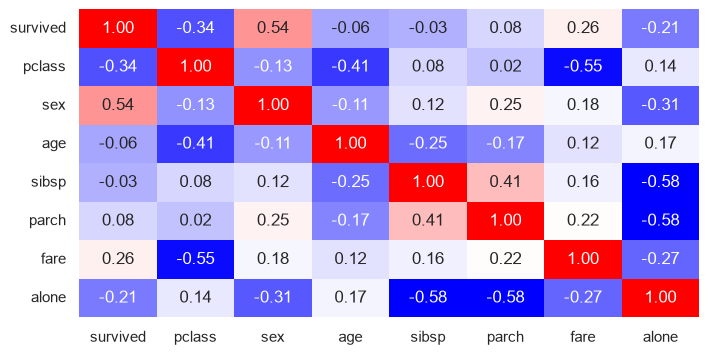

In [87]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

plt.figure(figsize=(8,4));

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='bwr', fmt='.2f', cbar=False);



**Boxplot**

 - Olha distribuição de variáveis
 - Separado em quartis
 - Vizualização de outliers


*Medidas Separatrizes*

 - Separam os dados em partes iguais(quantis).
 - Mais comuns: percentis e quantis
 
       - Percentis => Divide os dados em 100 partes iguais, e representam uma porcentagem aculmulada
       - Quantis => Dividem os dados em 4 partes iguais, cada uma com 25% das observações

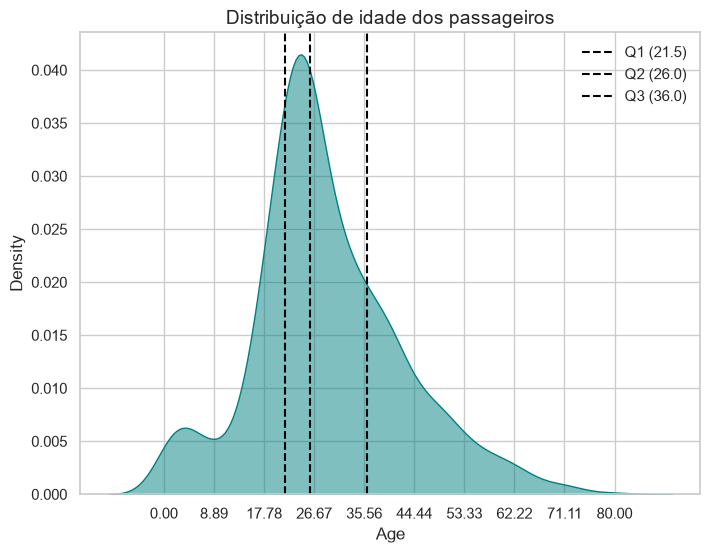

In [88]:
sns.set_theme(style='whitegrid')

age_data = df['age'].dropna()

q1 = age_data.quantile(0.25)
q2 = age_data.quantile(0.50)
q3 = age_data.quantile(0.75);

plt.figure(figsize=(8,6));

sns.kdeplot(data=age_data, fill=True, color='teal', alpha=0.5);

plt.axvline(x=q1, color='black', linestyle='--', label=f'Q1 ({q1:.1f})');
plt.axvline(x=q2, color='black', linestyle='--', label=f'Q2 ({q2:.1f})');
plt.axvline(x=q3, color='black', linestyle='--', label=f'Q3 ({q3:.1f})');
plt.title('Distribuição de idade dos passageiros', fontsize=14);
plt.xlabel('Age');
plt.ylabel('Density');
plt.xticks(np.linspace(0, 80, 10))
plt.legend()

In [89]:
df['fare'].describe()

count    889.000000
mean      32.096681
std       49.697504
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

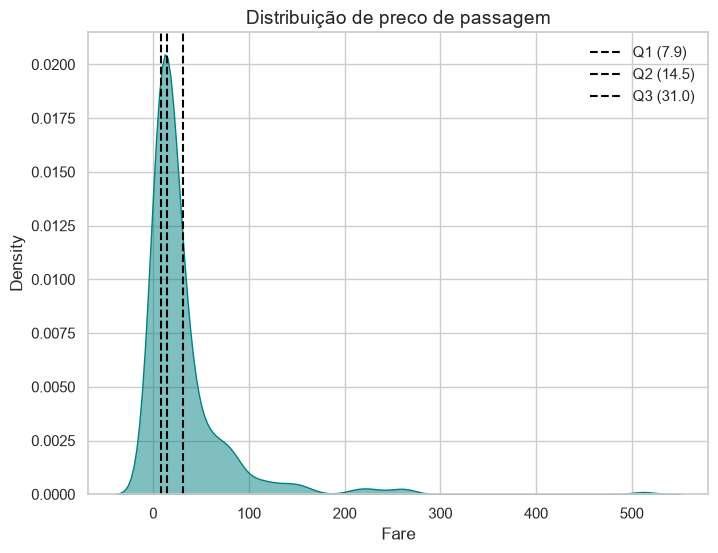

In [90]:
sns.set_theme(style='whitegrid')

fare_data = df['fare'].dropna()

q1 = fare_data.quantile(0.25)
q2 = fare_data.quantile(0.50)
q3 = fare_data.quantile(0.75);

plt.figure(figsize=(8,6));

sns.kdeplot(data=fare_data, fill=True, color='teal', alpha=0.5);

plt.axvline(x=q1, color='black', linestyle='--', label=f'Q1 ({q1:.1f})');
plt.axvline(x=q2, color='black', linestyle='--', label=f'Q2 ({q2:.1f})');
plt.axvline(x=q3, color='black', linestyle='--', label=f'Q3 ({q3:.1f})');
plt.title('Distribuição de preco de passagem', fontsize=14);
plt.xlabel('Fare');
plt.ylabel('Density');
plt.legend()

Text(0.5, 1.0, 'Boxplot of fare')

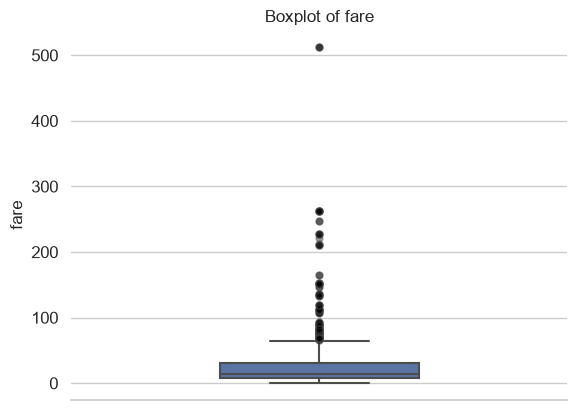

In [91]:
#Outliers são por padrão q3 + 1.5xIQR  ou q1 - 1.5xIQR
sns.set_theme(style="whitegrid")
sns.boxplot(
    data=df,
    y='fare', 
    color="#4C72B0", 
    width=0.4,       
    linewidth=1.5,
    flierprops={
        "marker": "o", 
        "markersize": 5, 
        "alpha": 0.4,          
        "markerfacecolor": "black"
    }
)
plt.tick_params(labelsize=12);
sns.despine(left=True)
plt.title('Boxplot of fare')

In [92]:
betterValue = df.loc[df['fare'].idxmax()]
betterValue

survived           1
pclass             1
sex                1
age             35.0
sibsp              0
parch              0
fare        512.3292
embarked           C
alone           True
Name: 258, dtype: object

**Relacionando e estudandos os dados com o sexo das pessoas**

 - Fare with sex and with alive
 - Survive with age


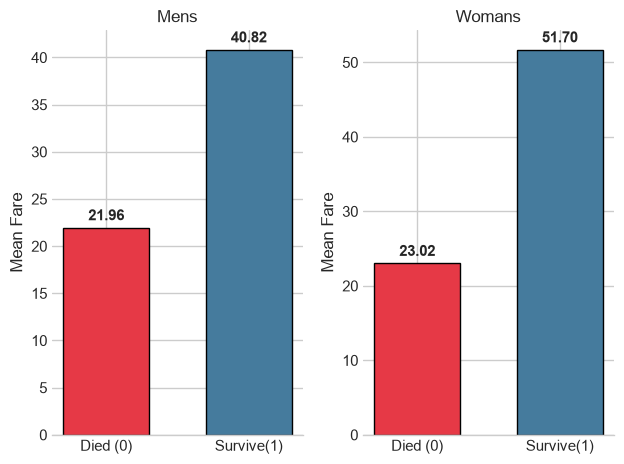

In [93]:
#Fare with sex and with alive
#0 =='male' and 1 'female'
fareBySex = df.groupby(['sex', 'survived'])['fare'].mean()

plt.style.use('seaborn-v0_8-whitegrid')

fig, axs = plt.subplots(1, 2, layout='tight')
axs[0].set_title('Mens')
axs[0].bar(['Died (0)', 'Survive(1)'], fareBySex[0].values, color=['#e63946', '#457b9d'], edgecolor='black', width=0.6)
axs[0].set_ylabel('Mean Fare')

axs[1].set_title('Womans')
axs[1].bar(['Died (0)', 'Survive(1)'], fareBySex[1].values, color=['#e63946', '#457b9d'], edgecolor='black', width=0.6)
axs[1].set_ylabel('Mean Fare')

for ax in axs:
    ax.tick_params(axis='x', rotation=0, labelsize=11)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

sns.despine(left=True)

Text(0.5, 0.98, 'Age distribution by survival status')

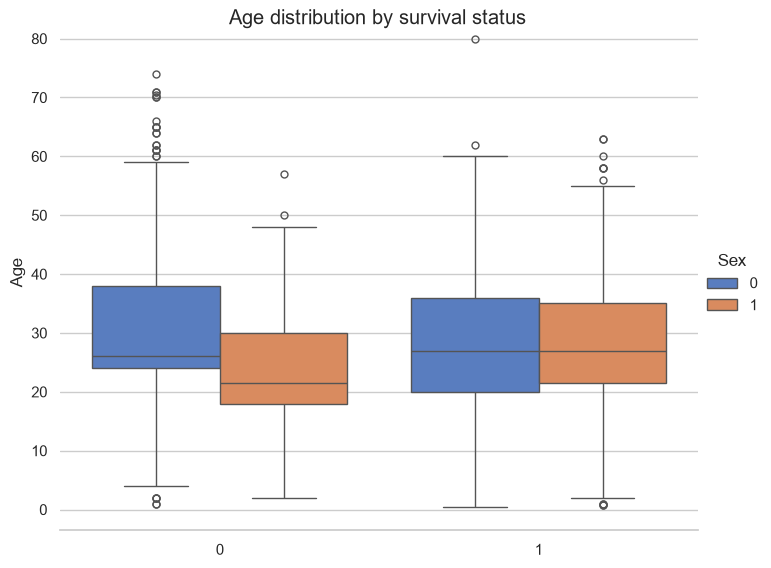

In [94]:
#Survive with age
sns.set_theme(style='whitegrid')

ags = sns.catplot(
    data=df,
    kind='box',
    x='survived', y='age', hue='sex',
    errorbar='sd',
    palette='muted', height=6, aspect=1.2
)

ags.despine(left=True)
ags.set_axis_labels('', 'Age');
ags.legend.set_title('Sex');
ags.fig.suptitle('Age distribution by survival status')

**Aplicando Machine Learnig no Titanic Dataset**

In [95]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,0,22.0,1,0,7.2500,S,False
1,1,1,1,38.0,1,0,71.2833,C,False
2,1,3,1,26.0,0,0,7.9250,S,True
3,1,1,1,35.0,1,0,53.1000,S,False
4,0,3,0,35.0,0,0,8.0500,S,True


In [96]:
from sklearn import svm
from sklearn.model_selection import train_test_split
classfier = svm.LinearSVC()

In [97]:
features = df[['sex', 'age', 'pclass']]
labels = df[['survived']]

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

classfier.fit(X_train, y_train)

c:\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [98]:
taxa = classfier.score(X_test, y_test)
print(f'{taxa*100:.2f}%')



81.46%


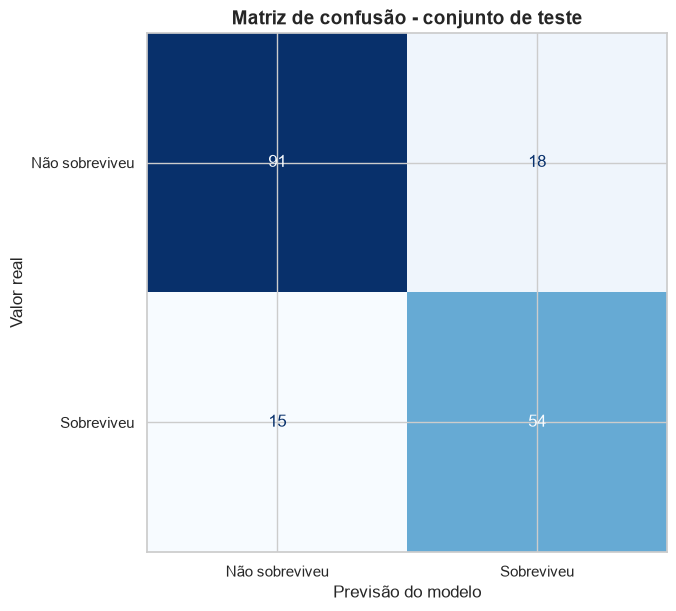

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Previsões para o conjunto de teste
y_pred = classfier.predict(X_test)
y_test_values = y_test.to_numpy().ravel()

matriz = confusion_matrix(y_test_values, y_pred)

fig, ax = plt.subplots(figsize=(7, 6), layout='constrained')
ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Não sobreviveu', 'Sobreviveu']
).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d'
)

ax.set_title('Matriz de confusão - conjunto de teste', fontsize=14, fontweight='bold')
ax.set_xlabel('Previsão do modelo')
ax.set_ylabel('Valor real')
plt.show()